# **Execução de Modelo TFLite (YOLO)**

Este notebook executa inferências em imagens ou vídeos utilizando o modelo exportado no formato **TFLite** (`.tflite`).

---

## **1. Instalar as Dependências**

In [2]:
# Instala a ultralytics e o interpretador tflite do TensorFlow
!pip install -q -U ultralytics opencv-python-headless

## **2. Carregar o Arquivo TFLite e Arquivos de Teste**

Faça o upload do seu arquivo `.tflite` gerado anteriormente e da imagem ou vídeo de teste no ambiente do Colab.

In [3]:
from google.colab import files
import os

## **3. Executar Detecção em Imagem**

Modelo descompactado com sucesso!
Carregando o modelo: best_saved_model/best.tflite


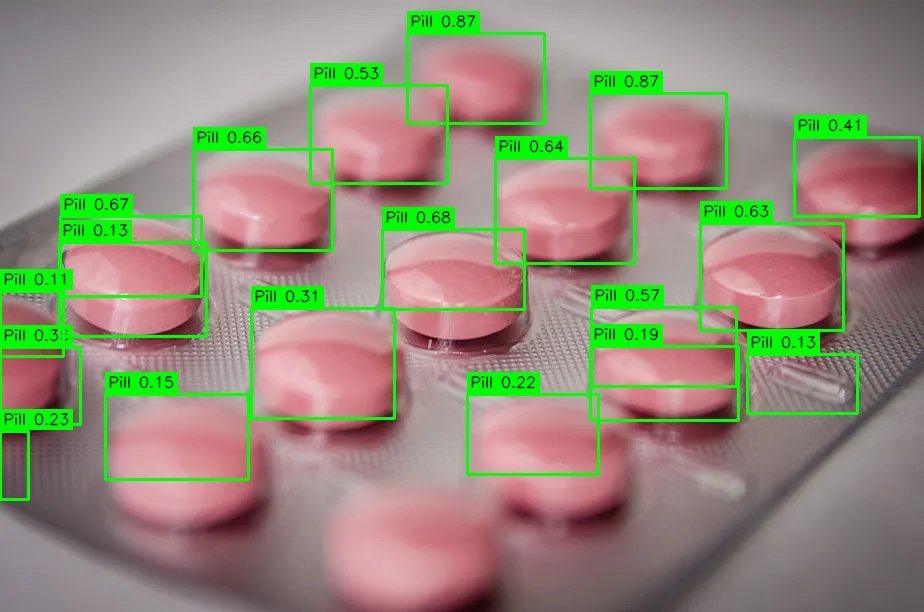

In [11]:
import cv2
import numpy as np
import tensorflow as tf
import zipfile
import os
from IPython.display import display, Image

# 1. Descompacta o modelo enviado em formato .zip
if os.path.exists('modelo_tflite.zip'):
    with zipfile.ZipFile('modelo_tflite.zip', 'r') as zip_ref:
        zip_ref.extractall('best_saved_model')
    print("Modelo descompactado com sucesso!")

# 2. Localiza o arquivo .tflite extraído
tflite_model_path = None
for root, dirs, files in os.walk('best_saved_model'):
    for file in files:
        if file.endswith('.tflite'):
            tflite_model_path = os.path.join(root, file)
            break

if not tflite_model_path or not os.path.isfile(tflite_model_path):
    raise FileNotFoundError("Nenhum arquivo .tflite válido foi encontrado na pasta descompactada.")

print(f"Carregando o modelo: {tflite_model_path}")

# 3. Inicializa o interpretador nativo do TensorFlow Lite
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
input_dtype = input_details[0]['dtype']

# 4. Carrega e pré-processa a imagem
image_path = 'sua_imagem.jpg'
image_orig = cv2.imread(image_path)
if image_orig is None:
    raise FileNotFoundError(f"A imagem '{image_path}' não foi encontrada.")

h_orig, w_orig, _ = image_orig.shape

# Converte de BGR (OpenCV) para RGB e redimensiona para 640x640
img_rgb = cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))

# Normaliza para [0, 1]
input_data = img_resized.astype(np.float32) / 255.0

# Ajusta a ordem das dimensões conforme esperado pelo modelo (NHWC x NCHW)
if input_shape[1] == 3:  # Formato NCHW: (1, 3, 640, 640)
    input_data = np.transpose(input_data, (2, 0, 1))

input_data = np.expand_dims(input_data, axis=0).astype(input_dtype)

# 5. Executa a inferência
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Obtém a saída do modelo
output_data = interpreter.get_tensor(output_details[0]['index'])

# 6. Pós-processamento e desenho das caixas com rótulo estilizado
conf_threshold = 0.1  # Limiar ajustado para capturar detecções do modelo inicial
iou_threshold = 0.45
boxes = []
scores = []

predictions = np.squeeze(output_data)
if predictions.shape[0] < predictions.shape[1]:
    predictions = predictions.T

for pred in predictions:
    class_scores = pred[4:]
    confidence = float(np.max(class_scores) if len(class_scores) > 0 else pred[4])

    if confidence >= conf_threshold:
        cx, cy, w, h = pred[0], pred[1], pred[2], pred[3]

        # Ajuste de escala automático para a dimensão original da imagem
        if cx <= 1.0 and cy <= 1.0:
            cx *= w_orig
            cy *= h_orig
            w *= w_orig
            h *= h_orig
        else:
            cx = cx * (w_orig / 640.0)
            cy = cy * (h_orig / 640.0)
            w = w * (w_orig / 640.0)
            h = h * (h_orig / 640.0)

        x1 = int(cx - w / 2)
        y1 = int(cy - h / 2)
        bw = int(w)
        bh = int(h)

        boxes.append([x1, y1, bw, bh])
        scores.append(confidence)

# Aplica Non-Maximum Suppression (NMS) com argumentos posicionais
indices = cv2.dnn.NMSBoxes(boxes, scores, conf_threshold, iou_threshold)

# Estilização visual (cor verde BGR)
color = (0, 255, 0)

if len(indices) > 0:
    for i in indices.flatten():
        x, y, w, h = boxes[i]
        score = scores[i]

        # 1. Desenha a caixa delimitadora externa
        cv2.rectangle(image_orig, (x, y), (x + w, y + h), color, 2)

        # 2. Configura a etiqueta preenchida no topo da caixa
        label_text = f"Pill {score:.2f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_thickness = 1

        # Calcula tamanho do texto para moldar a etiqueta
        (text_w, text_h), _ = cv2.getTextSize(label_text, font, font_scale, font_thickness)

        # 3. Desenha o fundo preenchido da etiqueta
        tag_y_top = max(0, y - text_h - 10)
        cv2.rectangle(
            image_orig,
            (x, tag_y_top),
            (x + text_w + 6, tag_y_top + text_h + 8),
            color,
            -1  # Preenchimento sólido
        )

        # 4. Escreve o texto em preto sobre o fundo verde
        cv2.putText(
            image_orig,
            label_text,
            (x + 3, tag_y_top + text_h + 3),
            font,
            font_scale,
            (0, 0, 0),  # Cor preta
            font_thickness,
            cv2.LINE_AA
        )

# Salva e exibe a imagem final
output_filename = 'resultado_deteccao.jpg'
cv2.imwrite(output_filename, image_orig)
display(Image(filename=output_filename))

## **4. Executar Detecção em Vídeo (Opcional)**

In [ ]:
# Substitua pelo caminho exato do seu vídeo
video_path = 'seu_video.mp4'

# O resultado processado ficará salvo em runs/detect/predict/
!yolo task=detect mode=predict model={tflite_model_path} conf=0.5 source={video_path}